In [2]:
import pandas as pd
import requests
from bs4 import BeautifulSoup


In [3]:
response=requests.get("https://www.ambitionbox.com/list-of-companies")

response

<Response [403]>

In [4]:
##### as we see above it shhow html code 403 which mean  bad request or access denied we can see the full msg using    `text` keyword

In [5]:
response.text

'<HTML><HEAD>\n<TITLE>Access Denied</TITLE>\n</HEAD><BODY>\n<H1>Access Denied</H1>\n \nYou don\'t have permission to access "http&#58;&#47;&#47;www&#46;ambitionbox&#46;com&#47;list&#45;of&#45;companies" on this server.<P>\nReference&#32;&#35;18&#46;b6055a68&#46;1782451384&#46;1506c758\n<P>https&#58;&#47;&#47;errors&#46;edgesuite&#46;net&#47;18&#46;b6055a68&#46;1782451384&#46;1506c758</P>\n</BODY>\n</HTML>\n'

##### this problem occur due to the the web server finds that the request send is for scripitng not from browser 
##### to solve this probelm we use  `header` keyword which disguise the server that request made by the browser

In [6]:
headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/137.0.0.0 Safari/537.36"
    ),
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://www.google.com/",
}





In [7]:
response=requests.get("https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav&page=1",headers=headers)


<!doctype html>
<html data-n-head-ssr lang="en" data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D">
  <head >
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width,initial-scale=1,minimum-scale=1">
    <meta http-equiv="X-UA-Compatible" content="IE=edge"> 
    <link rel="manifest" href="/assets/next/manifest.json">
    <style>@media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}</style>
    <script src="/static/js/env-runtime.js" defer></script>
    <script>window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()</script>
    <script>window.Prism=window.Prism||{},window.Prism.manual=!0</script>
    <title>Top Companies in India | AmbitionBox</title><meta data-n-head="ssr" name="copyright" content="2026 AmbitionBox"><meta data-n-head="ssr" name="revisit-after" content="1 day"><meta data-n-head="ss
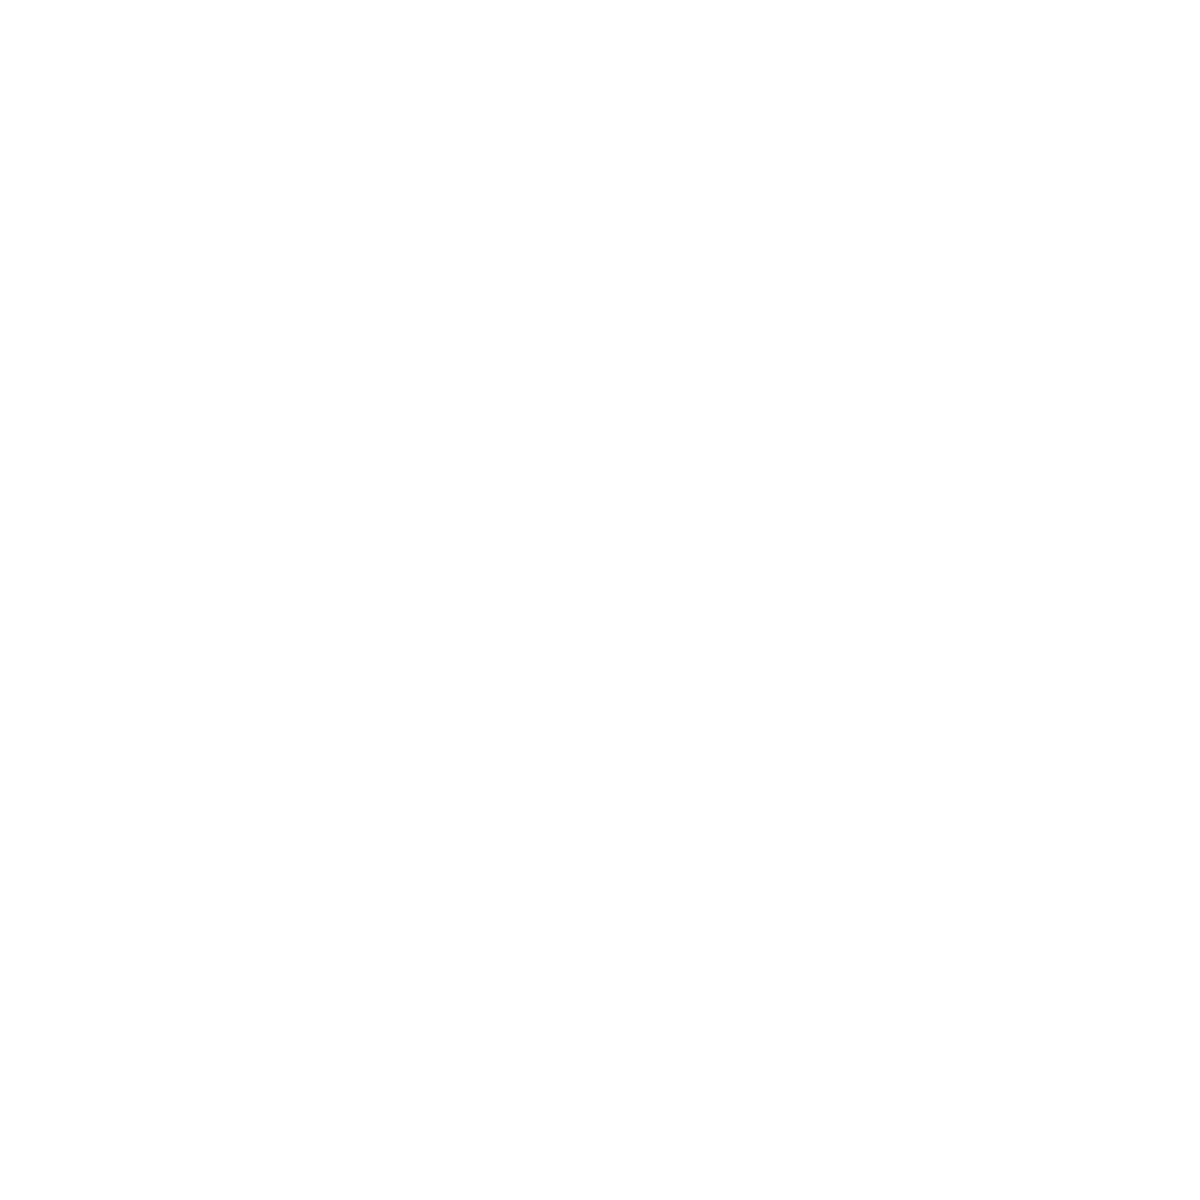

In [8]:
print(response.text)

now we have whole html pages

##### to mining the html page we use soup 

#### now we go to the website and open inspect section to understand the format of html

In [9]:

soup = BeautifulSoup(response.text, "lxml")

In [ ]:
soup.find_all('h2')

'Companies in India'

#### now i want to print all list of company on page no  1  and as i know alll company name is in h2 tag by inspect

In [27]:
for i in soup.find_all('h2'):
    print(i.text.strip())

Companies in India
TCS
Accenture
Wipro
Cognizant
Capgemini
HDFC Bank
Infosys
HCLTech
ICICI Bank
Tech Mahindra
Genpact
TP
Jio
Axis Bank
Concentrix Corporation
Amazon
Reliance Retail
iEnergizer
LTIMindtree
HDB Financial Services
Popular Collections by Industries
Popular Collections by Cities
Popular Collections by Roles


now i want to print all ratigs of all company 

In [38]:

company=soup.find_all('div',class_="companyCardWrapper")

len(company)

20

In [39]:
for i in company:
    print(i.find('h2'))

<h2 class="companyCardWrapper__companyName" title="TCS">
									TCS
								</h2>
<h2 class="companyCardWrapper__companyName" title="Accenture">
									Accenture
								</h2>
<h2 class="companyCardWrapper__companyName" title="Wipro">
									Wipro
								</h2>
<h2 class="companyCardWrapper__companyName" title="Cognizant">
									Cognizant
								</h2>
<h2 class="companyCardWrapper__companyName" title="Capgemini">
									Capgemini
								</h2>
<h2 class="companyCardWrapper__companyName" title="HDFC Bank">
									HDFC Bank
								</h2>
<h2 class="companyCardWrapper__companyName" title="Infosys">
									Infosys
								</h2>
<h2 class="companyCardWrapper__companyName" title="HCLTech">
									HCLTech
								</h2>
<h2 class="companyCardWrapper__companyName" title="ICICI Bank">
									ICICI Bank
								</h2>
<h2 class="companyCardWrapper__companyName" title="Tech Mahindra">
									Tech Mahindra
								</h2>
<h2 class="companyCardWrapper__companyName" title="Genpact

In [40]:
company_name=[]

for i in company :
    company_name.append(i.find('h2').text.strip())

In [41]:
company_name

['TCS',
 'Accenture',
 'Wipro',
 'Cognizant',
 'Capgemini',
 'HDFC Bank',
 'Infosys',
 'HCLTech',
 'ICICI Bank',
 'Tech Mahindra',
 'Genpact',
 'TP',
 'Jio',
 'Axis Bank',
 'Concentrix Corporation',
 'Amazon',
 'Reliance Retail',
 'iEnergizer',
 'LTIMindtree',
 'HDB Financial Services']

In [45]:
#### now try to extract rating count that is how many people give rating 

for i in company:
    print(i.find('span', class_="companyCardWrapper__companyRatingCount").text.strip())

(1.2L)
(74.8k)
(66.1k)
(62.4k)
(54.5k)
(53.5k)
(49.6k)
(46.8k)
(46.6k)
(44k)
(43.2k)
(39.4k)
(33.9k)
(33.9k)
(32.8k)
(32.2k)
(27.7k)
(27.4k)
(26.9k)
(26.1k)


In [49]:
# lets now extract actual rating

for i in company:
    print(i.find('div',class_="rating_star_container").text.strip())

3.3
3.7
3.6
3.7
3.6
3.8
3.5
3.4
3.9
3.3
3.6
3.9
4.4
3.6
3.6
3.9
3.9
4.6
3.6
3.9
